In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
import altair as alt
import plotly.express as px
import plotly.graph_objects as go
import great_tables as tg
import datetime as dt
import numpy as np
import pandas as pd
from babel.dates import match_skeleton
from imblearn.over_sampling import SMOTE
from io import StringIO

In [110]:
df_path = r"F:\Datasets\CSV datasets\YoutubeCommentsDataSet.csv"

In [111]:
df = pl.read_csv(df_path, try_parse_dates=True)

In [112]:
df.filter(
    pl.col('Comment').is_null()
)

Comment,Sentiment
str,str
null,"""negative"""
null,"""neutral"""
null,"""positive"""
null,"""positive"""
null,"""neutral"""
…,…
null,"""positive"""
null,"""neutral"""
null,"""positive"""


In [113]:
df = df.drop_nulls()

In [114]:
df.collect_schema()

Schema([('Comment', String), ('Sentiment', String)])

In [115]:
from sklearn.feature_extraction.text import CountVectorizer

In [116]:
count_vectorize = CountVectorizer(
    max_features=5000,
    stop_words='english', ngram_range=(1, 2),
    min_df=2
)

In [117]:
count_matrix = count_vectorize.fit_transform(df['Comment'])

In [118]:
count_df = pl.DataFrame(count_matrix.toarray(), schema=list(count_vectorize.get_feature_names_out()))

In [119]:
count_df.select(count_df.columns[:10])

000,000 intro,0000,0018,0018 joonie,10,10 und,10 years,100,1000
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0
…,…,…,…,…,…,…,…,…,…
0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0


In [120]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [121]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
)

In [122]:
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Comment'])

In [123]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 223768 stored elements and shape (18364, 5000)>

In [124]:
from sklearn.model_selection import train_test_split

In [125]:
X = df['Comment']
y = df['Sentiment']

In [126]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [127]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [128]:
from sklearn.preprocessing import LabelEncoder

In [129]:
label_encoder = LabelEncoder()

In [130]:
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [131]:
from sklearn.linear_model import LogisticRegression

In [132]:
log_reg = LogisticRegression()

In [133]:
log_reg.fit(X_train_tfidf, y_train_encoded)

LogisticRegression()

In [134]:
y_pred = log_reg.predict(X_test_tfidf)

In [135]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, ConfusionMatrixDisplay

In [136]:
accuracy_score(y_test_encoded, y_pred)

0.7394500408385516

In [137]:
predicted_sentiments = label_encoder.inverse_transform(y_pred)
predicted_sentiments

array(['neutral', 'neutral', 'positive', ..., 'positive', 'positive',
       'positive'], shape=(3673,), dtype='<U8')

In [138]:
from sklearn.model_selection import cross_val_score

In [139]:
scores = cross_val_score(log_reg, X_train_tfidf, y_train_encoded, cv=5, scoring='accuracy')

In [140]:
scores

array([0.74276965, 0.73791695, 0.75663717, 0.74948945, 0.7447243 ])

In [141]:
scores.mean()

np.float64(0.7463075037679006)

In [142]:
from sklearn.model_selection import GridSearchCV

In [143]:
param_grid = [
    {
        'penalty': [None],
        'class_weight': [None, 'balanced'],
        'solver': ['saga'],
        'max_iter': [10000]
    }
]

In [144]:
log_reg_cv = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    verbose=2,
    n_jobs=10,
    scoring='accuracy'
)

In [145]:
log_reg_cv.fit(X_train_tfidf, y_train_encoded)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=10,
             param_grid=[{'class_weight': [None, 'balanced'],
                          'max_iter': [10000], 'penalty': [None],
                          'solver': ['saga']}],
             scoring='accuracy', verbose=2)

In [146]:
log_reg_cv.best_params_

{'class_weight': None, 'max_iter': 10000, 'penalty': None, 'solver': 'saga'}

In [147]:
log_reg_cv.best_score_

np.float64(0.688041110939454)

In [148]:
log_reg_cv.best_estimator_

LogisticRegression(max_iter=10000, penalty=None, solver='saga')

In [149]:
y_pred = log_reg_cv.predict(X_test_tfidf)

In [150]:
accuracy_score(y_test_encoded, y_pred)

0.674108358290226

In [151]:
logistic_cv_result = pl.DataFrame({
    'Model': ['Logistic Regression'],
    'Accuracy': [accuracy_score(y_test_encoded, y_pred)],
    'F1 Score': [f1_score(y_test_encoded, y_pred, average='weighted')],
    # 'Cross Validation Score': [scores.mean()],
})
logistic_cv_result

Model,Accuracy,F1 Score
str,f64,f64
"""Logistic Regression""",0.674108,0.678105


In [152]:
print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.39      0.44      0.41       441
           1       0.49      0.50      0.50       912
           2       0.81      0.79      0.80      2320

    accuracy                           0.67      3673
   macro avg       0.57      0.58      0.57      3673
weighted avg       0.68      0.67      0.68      3673



In [153]:
conf_matrix = confusion_matrix(y_test_encoded, y_pred)
conf_matrix

array([[ 194,  134,  113],
       [ 149,  460,  303],
       [ 153,  345, 1822]])

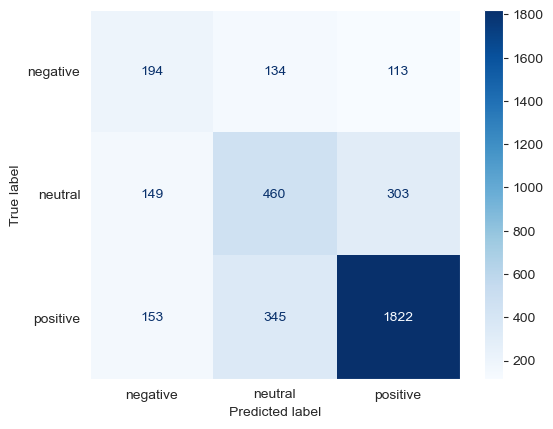

In [154]:
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred, cmap='Blues',
    display_labels=label_encoder.classes_
).ax_.grid(False)

In [209]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [210]:
random_forest_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('rf', RandomForestClassifier(random_state=42)),
])

In [211]:
param_grid = [
    {
        'tfidf__max_features': [5000],
        'tfidf__ngram_range': [(1, 1)],
        'tfidf__min_df': [1, 2],
        'tfidf__max_df': [0.9, 1.0],
        'rf__n_estimators': [100, 300],
        'rf__max_depth': [10, 20, 30],
        'rf__min_samples_split': [2, 5],
        'rf__min_samples_leaf': [1, 2],
        'rf__max_features': ['sqrt', 'log2'],
        'rf__class_weight': ['balanced', 'balanced_subsample']
    }
]

In [212]:
random_forest_cv = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1,
    scoring='f1_weighted'
)

In [213]:
random_forest_cv.fit(X_train, y_train_encoded)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words='english')),
                                       ('rf',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'rf__class_weight': ['balanced',
                                               'balanced_subsample'],
                          'rf__max_depth': [10, 20, 30],
                          'rf__max_features': ['sqrt', 'log2'],
                          'rf__min_samples_leaf': [1, 2],
                          'rf__min_samples_split': [2, 5],
                          'rf__n_estimators': [100, 300],
                          'tfidf__max_df': [0.9, 1.0],
                          'tfidf__max_features': [5000],
                          'tfidf__min_df': [1, 2],
                          'tfidf__ngram_range': [(1, 1)]}],
             scoring='f1_weighted', verbose=2)

In [216]:
y_pred = random_forest_cv.predict(X_test)

In [217]:
accuracy_score(y_test_encoded, y_pred)

0.7236591342227062

In [218]:
print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.44      0.54      0.48       441
           1       0.57      0.63      0.60       912
           2       0.87      0.80      0.83      2320

    accuracy                           0.72      3673
   macro avg       0.63      0.65      0.64      3673
weighted avg       0.74      0.72      0.73      3673



In [219]:
conf_matrix = confusion_matrix(y_test_encoded, y_pred)
conf_matrix

array([[ 236,  107,   98],
       [ 162,  577,  173],
       [ 141,  334, 1845]])

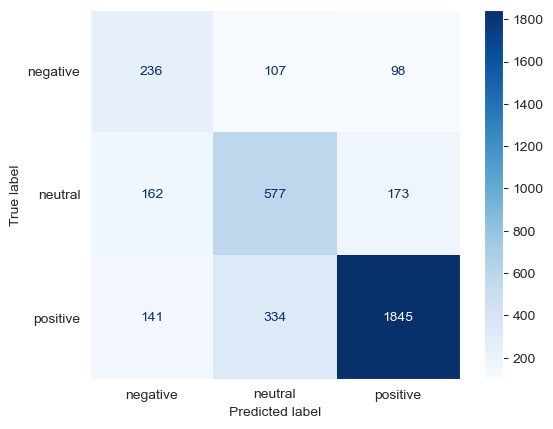

In [220]:
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred, cmap='Blues',
    display_labels=label_encoder.classes_
).ax_.grid(False)

In [221]:
# scores = cross_val_score(random_forest_pipeline, X_train, y_train_encoded, cv=5, scoring='accuracy')

In [222]:
result = pl.DataFrame({
    'Model': ['Random Forest CV'],
    'Accuracy': [accuracy_score(y_test_encoded, y_pred)],
    'F1 Score': [f1_score(y_test_encoded, y_pred, average='weighted')],
})
result

Model,Accuracy,F1 Score
str,f64,f64
"""Random Forest CV""",0.723659,0.731706


In [223]:
result = pl.concat([logistic_cv_result, result])

In [224]:
result

Model,Accuracy,F1 Score
str,f64,f64
"""Logistic Regression""",0.674108,0.678105
"""Random Forest CV""",0.723659,0.731706


In [225]:
from sklearn.ensemble import GradientBoostingClassifier

In [226]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('gb', GradientBoostingClassifier(random_state=42)),
])

In [227]:
param_grid = [
    {
        'tfidf__max_features': [5000],
        'tfidf__ngram_range': [(1, 1)],
        'tfidf__min_df': [2],
        'tfidf__max_df': [0.9],
        'gb__n_estimators': [100, 300],
        'gb__max_depth': [3, 5],
        'gb__min_samples_split': [2, 5],
        'gb__min_samples_leaf': [1, 2],
        'gb__max_features': ['sqrt'],
        'gb__learning_rate': [0.1, 0.01]
    }
]

In [228]:
gradient_boosting_cv = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1,
    scoring='f1_weighted'
)

In [229]:
gradient_boosting_cv.fit(X_train, y_train_encoded)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words='english')),
                                       ('gb',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'gb__learning_rate': [0.1, 0.01],
                          'gb__max_depth': [3, 5], 'gb__max_features': ['sqrt'],
                          'gb__min_samples_leaf': [1, 2],
                          'gb__min_samples_split': [2, 5],
                          'gb__n_estimators': [100, 300],
                          'tfidf__max_df': [0.9], 'tfidf__max_features': [5000],
                          'tfidf__min_df': [2],
                          'tfidf__ngram_range': [(1, 1)]}],
             scoring='f1_weighted', verbose=2)

In [231]:
y_pred = gradient_boosting_cv.predict(X_test)

In [232]:
pipeline_gradient_boosting_accuracy = accuracy_score(y_test_encoded, y_pred)
pipeline_gradient_boosting_accuracy

0.7184862510209638

In [233]:
gradient_boosting_result = pl.DataFrame({
    'Model': ['Gradient Boosting CV'],
    'Accuracy': [pipeline_gradient_boosting_accuracy],
    'F1 Score': [f1_score(y_test_encoded, y_pred, average='weighted')],
})

In [234]:
print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.23      0.34       441
           1       0.63      0.38      0.47       912
           2       0.74      0.95      0.83      2320

    accuracy                           0.72      3673
   macro avg       0.67      0.52      0.55      3673
weighted avg       0.70      0.72      0.68      3673



In [235]:
conf_matrix = confusion_matrix(y_test_encoded, y_pred)

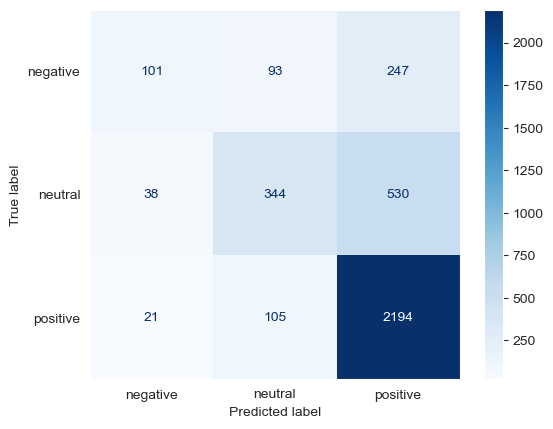

In [236]:
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred, cmap='Blues',
    display_labels=label_encoder.classes_
).ax_.grid(False)

In [237]:
result = pl.concat([result, gradient_boosting_result])

In [238]:
result

Model,Accuracy,F1 Score
str,f64,f64
"""Logistic Regression""",0.674108,0.678105
"""Random Forest CV""",0.723659,0.731706
"""Gradient Boosting CV""",0.718486,0.681681


In [239]:
from sklearn.svm import SVC

In [240]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('svc', SVC(random_state=42)),
])

In [242]:
param_grid = [
    {
        'tfidf__max_features': [5000],
        'tfidf__ngram_range': [(1, 1)],
        'tfidf__min_df': [2],
        'tfidf__max_df': [0.9],
        'svc__C': [1.0, 10.0],
        'svc__kernel': ['rbf', 'linear'],
        'svc__gamma': ['scale', 'auto'],
        'svc__class_weight': ['balanced', None]
    }]

In [243]:
svc_cv = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1,
    scoring='f1_weighted'
)

In [244]:
svc_cv.fit(X_train, y_train_encoded)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words='english')),
                                       ('svc', SVC(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'svc__C': [1.0, 10.0],
                          'svc__class_weight': ['balanced', None],
                          'svc__gamma': ['scale', 'auto'],
                          'svc__kernel': ['rbf', 'linear'],
                          'tfidf__max_df': [0.9], 'tfidf__max_features': [5000],
                          'tfidf__min_df': [2],
                          'tfidf__ngram_range': [(1, 1)]}],
             scoring='f1_weighted', verbose=2)

In [245]:
y_pred = svc_cv.predict(X_test)

In [246]:
pipeline_svc_accuracy = accuracy_score(y_test_encoded, y_pred)
pipeline_svc_accuracy

0.7359106997005173

In [249]:
print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.43      0.46       441
           1       0.55      0.69      0.61       912
           2       0.88      0.81      0.84      2320

    accuracy                           0.74      3673
   macro avg       0.64      0.64      0.64      3673
weighted avg       0.75      0.74      0.74      3673



In [ ]:
conf_matrix = confusion_matrix(y_test_encoded, y_pred)
conf_matrix

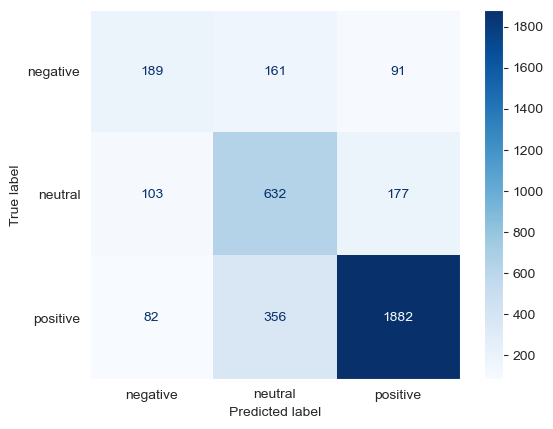

In [250]:
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred, cmap='Blues',
    display_labels=label_encoder.classes_
).ax_.grid(False)

In [251]:
svc_result = pl.DataFrame({
    'Model': ['Support Vector Classifier CV'],
    'Accuracy': [pipeline_svc_accuracy],
    'F1 Score': [f1_score(y_test_encoded, y_pred, average='weighted')],
})
svc_result

Model,Accuracy,F1 Score
str,f64,f64
"""Support Vector Classifier CV""",0.735911,0.739841


In [252]:
result = pl.concat([result, svc_result])
result

Model,Accuracy,F1 Score
str,f64,f64
"""Logistic Regression""",0.674108,0.678105
"""Random Forest CV""",0.723659,0.731706
"""Gradient Boosting CV""",0.718486,0.681681
"""Support Vector Classifier CV""",0.735911,0.739841


In [253]:
from sklearn.naive_bayes import MultinomialNB

In [254]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('nb', MultinomialNB()),
])

In [255]:
param_grid = [
    {
        'tfidf__max_features': [5000],
        'tfidf__ngram_range': [(1, 1)],
        'tfidf__min_df': [2],
        'tfidf__max_df': [0.9],
        'nb__alpha': [0.1, 1.0, 10.0],
    }]

In [256]:
nb_cv = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1,
    scoring='f1_weighted'
)

In [257]:
nb_cv.fit(X_train, y_train_encoded)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words='english')),
                                       ('nb', MultinomialNB())]),
             n_jobs=-1,
             param_grid=[{'nb__alpha': [0.1, 1.0, 10.0], 'tfidf__max_df': [0.9],
                          'tfidf__max_features': [5000], 'tfidf__min_df': [2],
                          'tfidf__ngram_range': [(1, 1)]}],
             scoring='f1_weighted', verbose=2)

In [258]:
y_pred = nb_cv.predict(X_test)

In [260]:
pipeline_nb_accuracy = accuracy_score(y_test_encoded, y_pred)
pipeline_nb_accuracy

0.7108630547236592

In [261]:
conf_matrix = confusion_matrix(y_test_encoded, y_pred)
conf_matrix

array([[ 138,   34,  269],
       [  80,  277,  555],
       [  27,   97, 2196]])

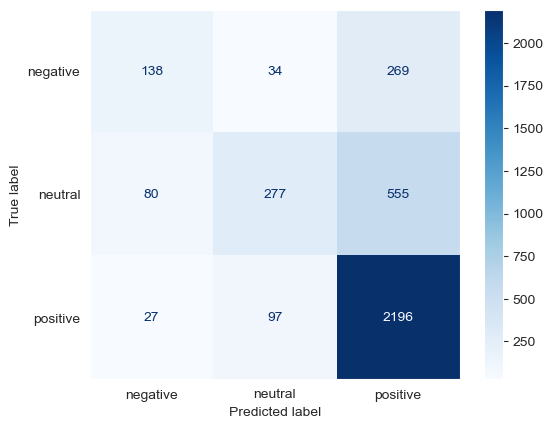

In [262]:
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred, cmap='Blues',
    display_labels=label_encoder.classes_
).ax_.grid(False)

In [263]:
print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.31      0.40       441
           1       0.68      0.30      0.42       912
           2       0.73      0.95      0.82      2320

    accuracy                           0.71      3673
   macro avg       0.66      0.52      0.55      3673
weighted avg       0.70      0.71      0.67      3673



In [264]:
nb_result = pl.DataFrame({
    'Model': ['Naive Bayes CV'],
    'Accuracy': [pipeline_nb_accuracy],
    'F1 Score': [f1_score(y_test_encoded, y_pred, average='weighted')],
})

In [265]:
result = pl.concat([result, nb_result])
result

Model,Accuracy,F1 Score
str,f64,f64
"""Logistic Regression""",0.674108,0.678105
"""Random Forest CV""",0.723659,0.731706
"""Gradient Boosting CV""",0.718486,0.681681
"""Support Vector Classifier CV""",0.735911,0.739841
"""Naive Bayes CV""",0.710863,0.672019


In [269]:
from sklearn.tree import DecisionTreeClassifier

In [270]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('dt', DecisionTreeClassifier(random_state=42)),
])

In [271]:
param_grid = [
    {
        'tfidf__max_features': [5000],
        'tfidf__ngram_range': [(1, 1)],
        'tfidf__min_df': [2],
        'tfidf__max_df': [0.9],
        'dt__max_depth': [10, 20, 30],
        'dt__min_samples_split': [2, 5],
        'dt__min_samples_leaf': [1, 2],
        'dt__max_features': ['sqrt', 'log2'],
        'dt__class_weight': ['balanced', None]
    }]

In [272]:
dt_cv = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1,
    scoring='f1_weighted'
)

In [274]:
dt_cv.fit(X_train, y_train_encoded)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words='english')),
                                       ('dt',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'dt__class_weight': ['balanced', None],
                          'dt__max_depth': [10, 20, 30],
                          'dt__max_features': ['sqrt', 'log2'],
                          'dt__min_samples_leaf': [1, 2],
                          'dt__min_samples_split': [2, 5],
                          'tfidf__max_df': [0.9], 'tfidf__max_features': [5000],
                          'tfidf__min_df': [2],
                          'tfidf__ngram_range': [(1, 1)]}],
             scoring='f1_weighted', verbose=2)

In [275]:
y_pred = dt_cv.predict(X_test)

In [277]:
pipeline_dt_accuracy = accuracy_score(y_test_encoded, y_pred)
pipeline_dt_accuracy

0.6297304655594882

In [278]:
conf_matrix = confusion_matrix(y_test_encoded, y_pred)
conf_matrix

array([[  57,    6,  378],
       [  42,   54,  816],
       [  87,   31, 2202]])

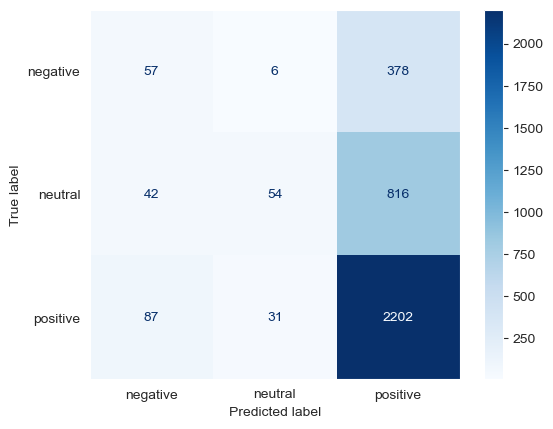

In [279]:
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred, cmap='Blues',
    display_labels=label_encoder.classes_
).ax_.grid(False)

In [280]:
print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.31      0.13      0.18       441
           1       0.59      0.06      0.11       912
           2       0.65      0.95      0.77      2320

    accuracy                           0.63      3673
   macro avg       0.52      0.38      0.35      3673
weighted avg       0.59      0.63      0.54      3673



In [281]:
dt_result = pl.DataFrame({
    'Model': ['Decision Tree CV'],
    'Accuracy': [pipeline_dt_accuracy],
    'F1 Score': [f1_score(y_test_encoded, y_pred, average='weighted')],
})

In [282]:
result = pl.concat([result, dt_result])
result

Model,Accuracy,F1 Score
str,f64,f64
"""Logistic Regression""",0.674108,0.678105
"""Random Forest CV""",0.723659,0.731706
"""Gradient Boosting CV""",0.718486,0.681681
"""Support Vector Classifier CV""",0.735911,0.739841
"""Naive Bayes CV""",0.710863,0.672019
"""Decision Tree CV""",0.62973,0.535222


In [283]:
from sklearn.svm import LinearSVC

In [284]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('svc', LinearSVC(random_state=42)),
])

In [285]:
param_grid = [
    {
        'tfidf__max_features': [5000],
        'tfidf__ngram_range': [(1, 1)],
        'tfidf__min_df': [2],
        'tfidf__max_df': [0.9],
        'svc__C': [1.0, 10.0],
        'svc__class_weight': ['balanced', None]
    }]

In [286]:
linear_svc_cv = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1,
    scoring='f1_weighted'
)

In [287]:
linear_svc_cv.fit(X_train, y_train_encoded)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words='english')),
                                       ('svc', LinearSVC(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'svc__C': [1.0, 10.0],
                          'svc__class_weight': ['balanced', None],
                          'tfidf__max_df': [0.9], 'tfidf__max_features': [5000],
                          'tfidf__min_df': [2],
                          'tfidf__ngram_range': [(1, 1)]}],
             scoring='f1_weighted', verbose=2)

In [288]:
y_pred = linear_svc_cv.predict(X_test)

In [289]:
pipeline_linear_svc_accuracy = accuracy_score(y_test_encoded, y_pred)

In [290]:
pipeline_linear_svc_accuracy

0.7301933024775388

In [291]:
conf_matrix = confusion_matrix(y_test_encoded, y_pred)
conf_matrix

array([[ 169,  139,  133],
       [ 107,  501,  304],
       [  76,  232, 2012]])

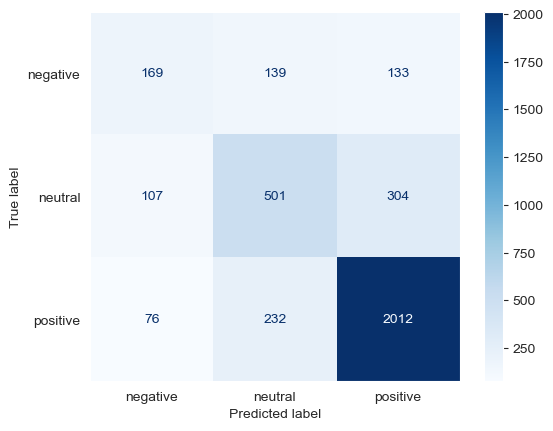

In [292]:
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred, cmap='Blues',
    display_labels=label_encoder.classes_
).ax_.grid(False)

In [293]:
print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.48      0.38      0.43       441
           1       0.57      0.55      0.56       912
           2       0.82      0.87      0.84      2320

    accuracy                           0.73      3673
   macro avg       0.63      0.60      0.61      3673
weighted avg       0.72      0.73      0.72      3673



In [294]:
linear_svc_result = pl.DataFrame({
    'Model': ['Linear SVC CV'],
    'Accuracy': [pipeline_linear_svc_accuracy],
    'F1 Score': [f1_score(y_test_encoded, y_pred, average='weighted')],
})

In [295]:
result = pl.concat([result, linear_svc_result])
result

Model,Accuracy,F1 Score
str,f64,f64
"""Logistic Regression""",0.674108,0.678105
"""Random Forest CV""",0.723659,0.731706
"""Gradient Boosting CV""",0.718486,0.681681
"""Support Vector Classifier CV""",0.735911,0.739841
"""Naive Bayes CV""",0.710863,0.672019
"""Decision Tree CV""",0.62973,0.535222
"""Linear SVC CV""",0.730193,0.723598
